# CATE estimation trough single class models

I this notebook we analize the CATE (Conditional Average Treatment Effect: CATE(X) = E[Y(1) − Y(0) | X]) over the two groups of patients.

This estimations helps us understand what is the unseen effect of the treatment on the two groups.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sys
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report

In [24]:
PROJECT_DIR = os.path.dirname(os.path.dirname('Bachelor-Thesis'))
MODULE_DIR = os.path.join(PROJECT_DIR, 'Meta-learning')
sys.path.append(MODULE_DIR)

# Uniform plot style for all project charts
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

import warnings
warnings.filterwarnings('ignore')

In [25]:
X = pd.read_parquet(os.path.join(PROJECT_DIR, '../data/X_features.parquet'))
y_df = pd.read_parquet(os.path.join(PROJECT_DIR, '../data/y_targets.parquet'))

target_features = y_df

s_df = X[X['regimen'] == 'abbreviated DAPT'].copy()

l_df = X[X['regimen'] == 'prolonged DAPT'].copy()

y_df = target_features.loc[X.index].copy()

In [26]:
MODELS_DIR = os.path.join('models')

import joblib

models = {}

for model_name in os.listdir(MODELS_DIR):
    path = os.path.join(MODELS_DIR, model_name)

    # Parse metadata from filename — adapt this to your naming convention
    algo = model_name[:2]
    suffix = model_name.split('_')[-1].replace('.pkl', '')
    variant_label = suffix  # or map via a lookup dict

    entry = {
        'pipeline': joblib.load(path),
        'algo': algo,
        'variant': suffix,
        'variant_label': variant_label,
    }

    if 'lDAPT' in model_name:
        long_dapt_model = entry
    if 'sDAPT' in model_name:
        short_dapt_model = entry


In [27]:
# ── CATE Estimation ──────────────────────────────────────────────────────────
# CATE(x) = E[Y | T=lDAPT, X=x] - E[Y | T=sDAPT, X=x]
# Positive CATE → lDAPT benefits the patient more
# Negative CATE → sDAPT is preferable

import numpy as np
import pandas as pd

# Predicted risk under each treatment arm
# Use predict_proba[:, 1] for classifiers, predict() for regressors
pipe_l = long_dapt_model['pipeline']
pipe_s = short_dapt_model['pipeline']

predict = lambda pipe, X: (
    np.array(pipe.predict_proba(X))[:, 1]
    if hasattr(pipe, 'predict_proba')
    else np.array(pipe.predict(X))
)

try:
    X.drop(['regimen'], axis=1, inplace=True)
except:
    pass

y_hat_lDAPT = predict(pipe_l, X)   # P(event | lDAPT)
y_hat_sDAPT = predict(pipe_s, X)   # P(event | sDAPT)

cate = y_hat_lDAPT - y_hat_sDAPT        # shape: (n_patients,)

n_targets = len(pipe_l.predict_proba(X))

cate_per_target = {}
for i in range(n_targets):
    y_l = np.array(pipe_l.predict_proba(X)[i])[:, 1]
    y_s = np.array(pipe_s.predict_proba(X)[i])[:, 1]
    cate_per_target[f'cate_{y_df.columns[i]}'] = y_l - y_s
    
    
cate_per_target = pd.DataFrame(cate_per_target)

target_names = list(cate_per_target.keys())
target_labels = ['barc_235', 'death', 'mi', 'stroke', 'bleed']
n = len(target_names)

In [33]:
from scipy import stats

y_l = y_df.loc[l_df.index]
y_s = y_df.loc[s_df.index]
observed_cols = [name.replace('cate_', '') for name in target_names]

print("Chi² Test: lDAPT vs sDAPT (dati osservati)\n")
print(f"{'Target':<20} {'chi2':>10} {'p-value':>12} {'rate_l':>9} {'rate_s':>9} {'Sig':>5}")
print("-" * 70)

chi2_results = {}
for col, label in zip(observed_cols, target_labels):
    ct = pd.crosstab(pd.concat([y_l[col], y_s[col]]),
                     ['lDAPT'] * len(y_l) + ['sDAPT'] * len(y_s))
    chi2, p_value, _, _ = stats.chi2_contingency(ct)
    chi2_results[col] = {'chi2': chi2, 'p_value': p_value}
    sig = "✓" if p_value < 0.05 else "✗"
    print(f"{label:<20} {chi2:>10.4f} {p_value:>12.4f} "
          f"{y_l[col].mean():>9.4f} {y_s[col].mean():>9.4f} {sig:>5}")


Chi² Test: lDAPT vs sDAPT (dati osservati)

Target                     chi2      p-value    rate_l    rate_s   Sig
----------------------------------------------------------------------
barc_235                11.9440       0.0005    0.0924    0.0645     ✓
death                    0.4823       0.4874    0.0193    0.0161     ✗
mi                       0.8912       0.3451    0.0215    0.0261     ✗
stroke                   2.9278       0.0871    0.0101    0.0052     ✗
bleed                   23.2136       0.0000    0.1331    0.0880     ✓


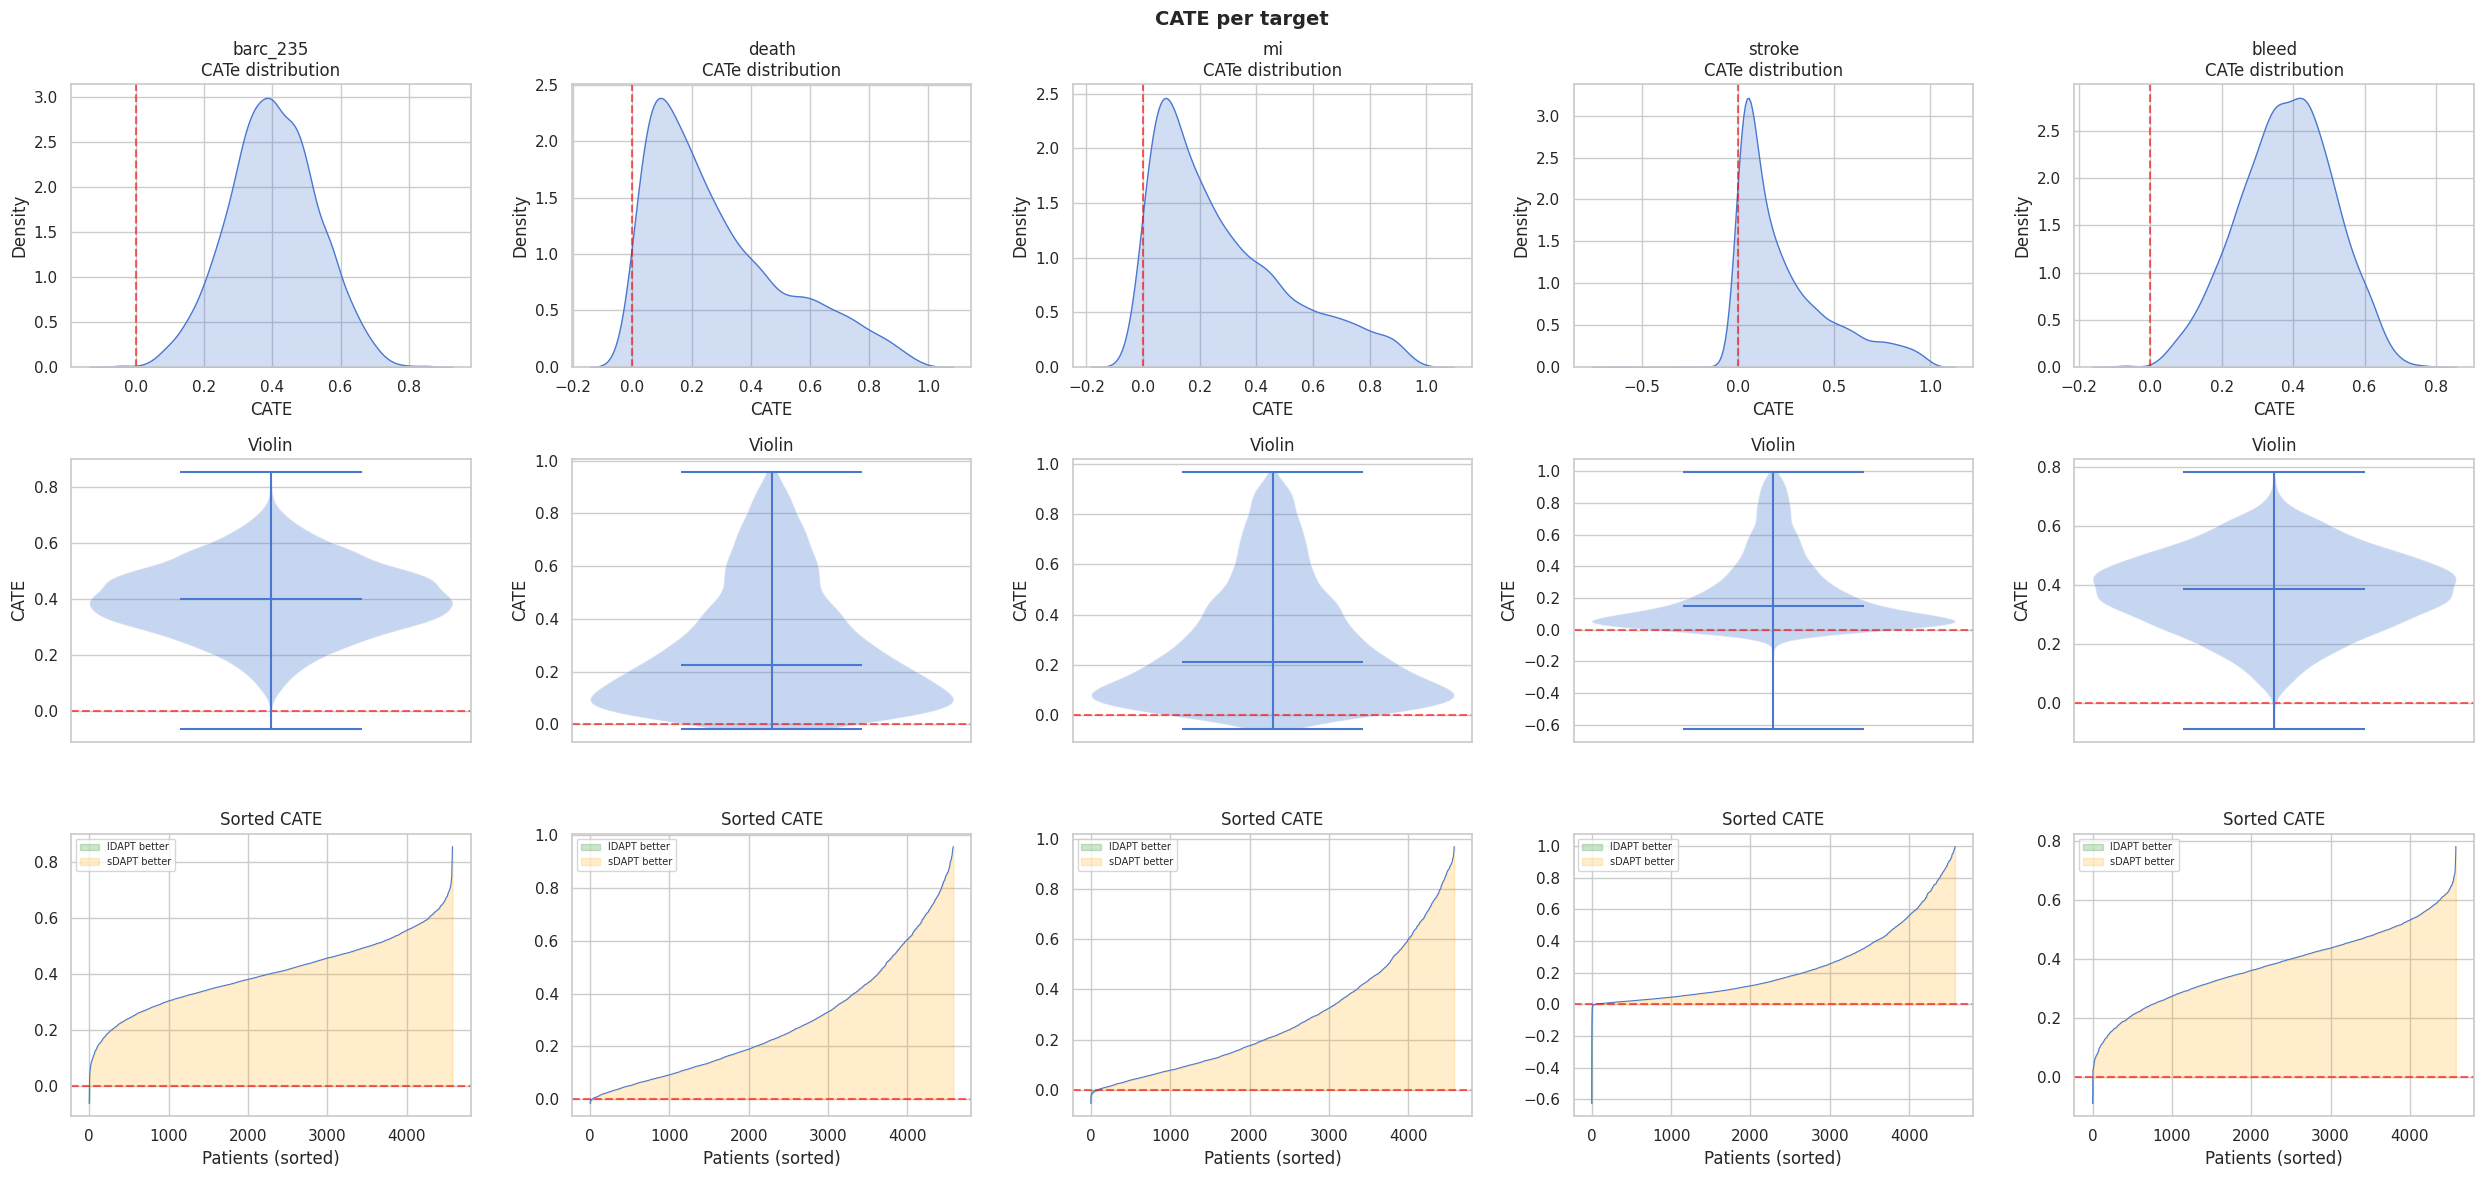

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, n, figsize=(5 * n, 12))
fig.suptitle("CATE per target", fontsize=14, fontweight='bold')

for i, name in enumerate(target_names):
    cate = cate_per_target[name]

    # ── 1. KDE distribution ──────────────────────────────────────────
    axes[0, i].axvline(0, color='red', linestyle='--', alpha=0.6, label='No effect')
    sns.kdeplot(cate, ax=axes[0, i], fill=True)
    axes[0, i].set_title(f'{target_labels[i]}\nCATe distribution')
    axes[0, i].set_xlabel('CATE')
    
    # ── 2. Violin plot ───────────────────────────────────────────────
    axes[1, i].axhline(0, color='red', linestyle='--', alpha=0.6)
    axes[1, i].violinplot(cate, showmedians=True)
    axes[1, i].set_title('Violin')
    axes[1, i].set_ylabel('CATE')
    axes[1, i].set_xticks([])

    # ── 3. Sorted CATE (uplift curve) ────────────────────────────────
    axes[2, i].plot(sorted(cate), linewidth=0.8)
    axes[2, i].axhline(0, color='red', linestyle='--', alpha=0.6)
    axes[2, i].fill_between(range(len(cate)), sorted(cate), 0,
                             where=[v < 0 for v in sorted(cate)],
                             alpha=0.2, color='green', label='lDAPT better')
    axes[2, i].fill_between(range(len(cate)), sorted(cate), 0,
                             where=[v > 0 for v in sorted(cate)],
                             alpha=0.2, color='orange', label='sDAPT better')
    axes[2, i].set_title('Sorted CATE')
    axes[2, i].set_xlabel('Patients (sorted)')
    axes[2, i].legend(fontsize=7)

plt.tight_layout()
plt.show()